In [5]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter("ignore")

In [8]:
df = pd.read_csv("ecommerce_data.csv")
df

,Order ID,Customer ID,Platform,Time,Delivery Time (Minutes),Product Category,Order Value (INR),Customer Feedback,Service Rating,Delivery Delay,Refund Requested
0,ORD000001,CUST2824,JioMart,12:19:29 AM,30,Fruits & Vegetables,382,"Fast delivery, great service!",5,No,No
1,ORD000002,CUST1409,Blinkit,12:54:30 AM,16,Dairy,279,Quick and reliable!,5,No,No
2,ORD000003,CUST5506,JioMart,12:21:29 AM,25,Beverages,599,Items missing from order.,2,No,Yes
3,ORD000004,CUST5012,JioMart,12:19:29 AM,42,Beverages,946,Items missing from order.,2,Yes,Yes
4,ORD000005,CUST4657,Blinkit,12:49:30 AM,30,Beverages,334,"Fast delivery, great service!",5,No,No
...,...,...,...,...,...,...,...,...,...,...,...
99995,ORD099996,CUST5324,JioMart,12:49:30 AM,24,Dairy,289,Packaging could be better.,3,No,No
99996,ORD099997,CUST1677,JioMart,12:18:30 AM,19,Snacks,322,Good quality products.,4,No,No
99997,ORD099998,CUST8198,JioMart,12:27:30 AM,41,Dairy,135,"Fast delivery, great service!",5,Yes,No
99998,ORD099999,CUST9975,JioMart,12:14:30 AM,31,Grocery,973,Quick and reliable!,5,No,No


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Order ID                 100000 non-null  object
 1   Customer ID              100000 non-null  object
 2   Platform                 100000 non-null  object
 3    Time                    100000 non-null  object
 4   Delivery Time (Minutes)  100000 non-null  int64 
 5   Product Category         100000 non-null  object
 6   Order Value (INR)        100000 non-null  int64 
 7   Customer Feedback        100000 non-null  object
 8   Service Rating           100000 non-null  int64 
 9   Delivery Delay           100000 non-null  object
 10  Refund Requested         100000 non-null  object
dtypes: int64(3), object(8)
memory usage: 8.4+ MB


In [28]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["Delivery Time (Minutes)"].describe().round(2)

count    100000.00
mean         29.54
std           9.96
min           5.00
25%          23.00
50%          30.00
75%          36.00
max          76.00
Name: Delivery Time (Minutes), dtype: float64

In [11]:
df["Order Value (INR)"].describe().round(2)

count    100000.00
mean        590.99
std         417.41
min          50.00
25%         283.00
50%         481.00
75%         770.00
max        2000.00
Name: Order Value (INR), dtype: float64

In [12]:
df["Service Rating"].describe().round(2)

count    100000.00
mean          3.24
std           1.58
min           1.00
25%           2.00
50%           3.00
75%           5.00
max           5.00
Name: Service Rating, dtype: float64

In [29]:
df["Service Rating"].unique().tolist()

[5, 2, 1, 4, 3]

In [30]:
df["Service Rating"].value_counts()

Service Rating
5    38688
2    30552
1    15267
4     7789
3     7704
Name: count, dtype: int64

In [14]:
df["Platform"].unique().tolist()

['JioMart', 'Blinkit', 'Swiggy Instamart']

In [15]:
df["Platform"].value_counts()

Platform
Swiggy Instamart    33449
Blinkit             33424
JioMart             33127
Name: count, dtype: int64

In [19]:
df["Product Category"].unique().tolist()

['Fruits & Vegetables',
 'Dairy',
 'Beverages',
 'Personal Care',
 'Grocery',
 'Snacks']

In [20]:
df["Product Category"].value_counts()

Product Category
Dairy                  16857
Grocery                16737
Snacks                 16705
Fruits & Vegetables    16632
Beverages              16536
Personal Care          16533
Name: count, dtype: int64

In [21]:
df["Delivery Delay"].unique().tolist()

['No', 'Yes']

In [22]:
df["Delivery Delay"].value_counts()

Delivery Delay
No     86328
Yes    13672
Name: count, dtype: int64

In [24]:
df["Refund Requested"].unique().tolist()

['No', 'Yes']

In [25]:
df["Refund Requested"].value_counts()

Refund Requested
No     54181
Yes    45819
Name: count, dtype: int64

In [84]:
continous = ["Delivery Time (Minutes)","Order Value (INR)","Service Rating"]
discrete_categorical = ["Platform","Product Category","Delivery Delay","Refund Requested"]
discrete_count = ["Order ID","Customer ID","Time"]
 

In [34]:
df[continous].describe()

,Delivery Time (Minutes),Order Value (INR)
count,100000.000000,100000.000000
mean,29.536140,590.994400
std,9.958933,417.409058
min,5.000000,50.000000
25%,23.000000,283.000000
50%,30.000000,481.000000
75%,36.000000,770.000000
max,76.000000,2000.000000


In [35]:
df[continous].skew()

Delivery Time (Minutes)    0.044513
Order Value (INR)          1.203128
dtype: float64

**right skewed distribution**

<Axes: xlabel='Delivery Time (Minutes)', ylabel='Count'>

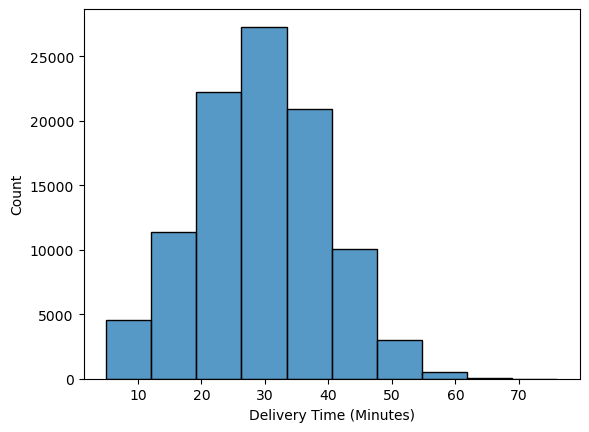

In [36]:
sns.histplot(df["Delivery Time (Minutes)"],bins=10)

<Axes: xlabel='Order Value (INR)', ylabel='Count'>

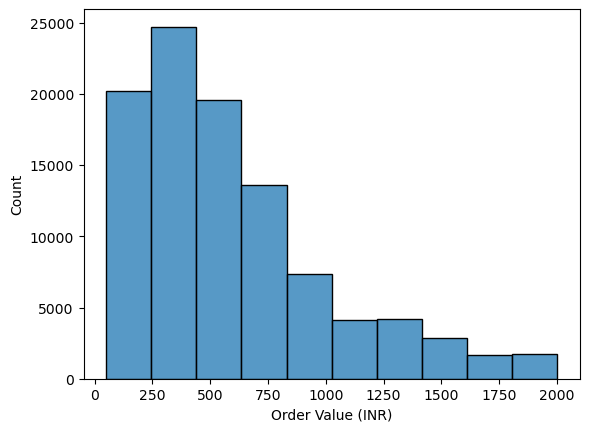

In [37]:
sns.histplot(df["Order Value (INR)"],bins=10)

<Axes: ylabel='Order Value (INR)'>

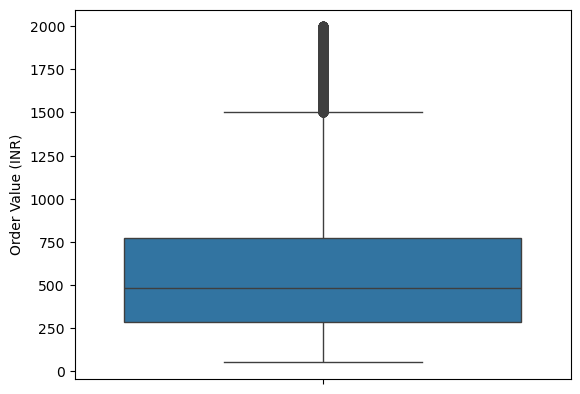

In [38]:
sns.boxplot(df["Order Value (INR)"])

<Axes: ylabel='Delivery Time (Minutes)'>

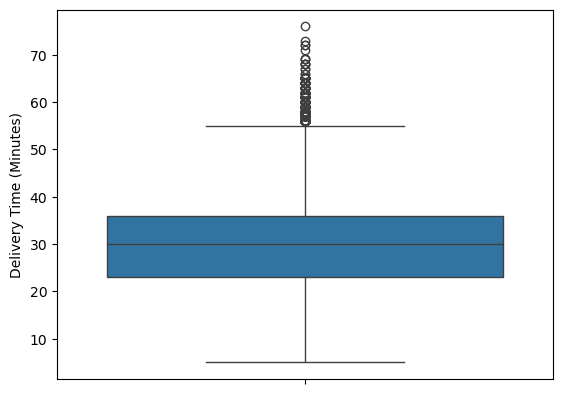

In [40]:
sns.boxplot(df["Delivery Time (Minutes)"])

**Observations**
- Outliers are present in this dataset but do not remove/replace

In [48]:
df[discrete_categorical].describe()

,Platform,Product Category,Delivery Delay,Refund Requested
count,100000,100000,100000,100000
unique,3,6,2,2
top,Swiggy Instamart,Dairy,No,No
freq,33449,16857,86328,54181


In [51]:
df[rating].describe()

,Service Rating
count,100000.000000
mean,3.240790
std,1.575962
min,1.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,5.000000


In [53]:
df.isnull().sum()

Order ID                   0
Customer ID                0
Platform                   0
 Time                      0
Delivery Time (Minutes)    0
Product Category           0
Order Value (INR)          0
Customer Feedback          0
Service Rating             0
Delivery Delay             0
Refund Requested           0
dtype: int64

**No null value**

In [55]:
df.groupby("Platform")["Order Value (INR)"].describe().transpose()

Platform,Blinkit,JioMart,Swiggy Instamart
count,33424.000000,33127.000000,33449.000000
mean,589.548947,590.526519,592.902150
std,415.895581,417.266064,419.062339
min,50.000000,50.000000,50.000000
25%,284.000000,282.000000,282.000000
50%,479.000000,480.000000,483.000000
75%,767.000000,770.000000,772.000000
max,2000.000000,2000.000000,2000.000000


In [56]:
df.groupby("Platform")["Customer Feedback"].describe().transpose()

Platform,Blinkit,JioMart,Swiggy Instamart
count,33424,33127,33449
unique,13,13,13
top,Wrong item delivered.,Items missing from order.,Very satisfied with the service.
freq,2638,2611,2626


**Observation**
- swiggy instamart's customers feedback are better as compared to 'blinkit' and 'jiomart'

In [58]:
df.groupby("Platform")["Service Rating"].describe().transpose()

Platform,Blinkit,JioMart,Swiggy Instamart
count,33424.000000,33127.000000,33449.000000
mean,3.233844,3.245147,3.243415
std,1.575231,1.575393,1.577278
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000
50%,3.000000,3.000000,3.000000
75%,5.000000,5.000000,5.000000
max,5.000000,5.000000,5.000000


In [59]:
df.groupby("Platform")["Delivery Time (Minutes)"].describe().transpose()

Platform,Blinkit,JioMart,Swiggy Instamart
count,33424.000000,33127.000000,33449.000000
mean,29.474898,29.634498,29.499925
std,9.965288,9.931226,9.979524
min,5.000000,5.000000,5.000000
25%,23.000000,23.000000,23.000000
50%,30.000000,30.000000,29.000000
75%,36.000000,36.000000,36.000000
max,76.000000,73.000000,69.000000


In [60]:
df.groupby("Product Category")["Order Value (INR)"].describe().transpose()

Product Category,Beverages,Dairy,Fruits & Vegetables,Grocery,Personal Care,Snacks
count,16536.000000,16857.000000,16632.000000,16737.000000,16533.000000,16705.000000
mean,549.508285,451.475470,375.572210,848.064468,1052.174499,273.335887
std,259.639983,201.772026,187.425089,376.487841,546.769945,130.999354
min,100.000000,100.000000,50.000000,200.000000,100.000000,50.000000
25%,324.000000,278.000000,213.000000,523.000000,581.000000,159.000000
50%,549.000000,454.000000,375.000000,849.000000,1050.000000,272.000000
75%,774.000000,626.000000,537.250000,1174.000000,1526.000000,388.000000
max,1000.000000,800.000000,700.000000,1500.000000,2000.000000,500.000000


In [61]:
df.groupby("Product Category")["Customer Feedback"].describe().transpose()

Product Category,Beverages,Dairy,Fruits & Vegetables,Grocery,Personal Care,Snacks
count,16536,16857,16632,16737,16533,16705
unique,13,13,13,13,13,13
top,Very satisfied with the service.,Very satisfied with the service.,Delivery person was rude.,Items missing from order.,"Fast delivery, great service!",Good quality products.
freq,1356,1339,1323,1330,1322,1355


In [69]:
pd.crosstab(df["Product Category"],df["Service Rating"])

Service Rating,1,2,3,4,5
Product Category,,,,,
Beverages,2539,5010,1260,1272,6455
Dairy,2575,5116,1332,1311,6523
Fruits & Vegetables,2543,5149,1277,1265,6398
Grocery,2550,5261,1270,1305,6351
Personal Care,2551,4966,1249,1281,6486
Snacks,2509,5050,1316,1355,6475


In [70]:
pd.crosstab(df["Platform"],df["Service Rating"])

Service Rating,1,2,3,4,5
Platform,,,,,
Blinkit,5141,10212,2599,2634,12838
JioMart,5000,10178,2514,2571,12864
Swiggy Instamart,5126,10162,2591,2584,12986


In [72]:
pd.crosstab(df["Platform"],df["Delivery Delay"])

Delivery Delay,No,Yes
Platform,,
Blinkit,28951,4473
JioMart,28547,4580
Swiggy Instamart,28830,4619


In [73]:
pd.crosstab(df["Platform"],df["Refund Requested"])

Refund Requested,No,Yes
Platform,,
Blinkit,18071,15353
JioMart,17949,15178
Swiggy Instamart,18161,15288


In [74]:
pd.crosstab(df["Delivery Delay"],df["Refund Requested"])

Refund Requested,No,Yes
Delivery Delay,,
No,46807,39521
Yes,7374,6298


In [85]:
c= df[continous].corr()
c

,Delivery Time (Minutes),Order Value (INR),Service Rating
Delivery Time (Minutes),1.000000,0.007225,0.000136
Order Value (INR),0.007225,1.000000,-0.002689
Service Rating,0.000136,-0.002689,1.000000


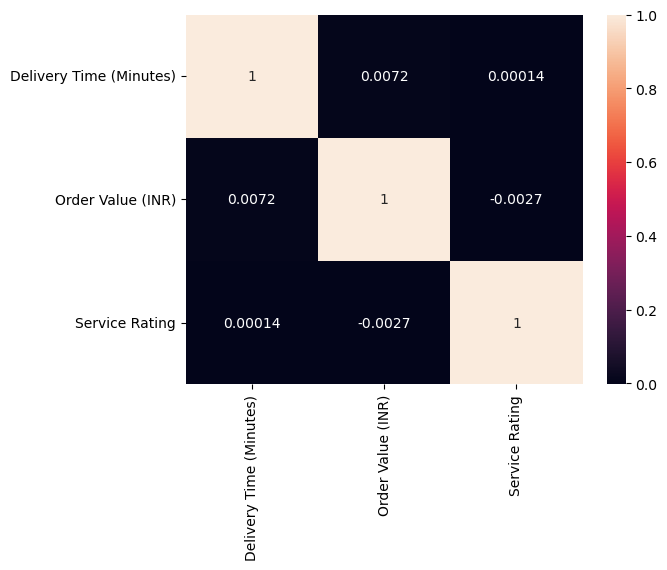

In [86]:
sns.heatmap(c,annot=True)
plt.show()

In [90]:
pd.crosstab(df["Order Value (INR)"],df["Service Rating"]).describe().round(2)

Service Rating,1,2,3,4,5
count,1951.00,1951.00,1951.00,1951.00,1951.00
mean,7.83,15.66,3.95,3.99,19.83
std,7.16,14.09,3.93,4.00,17.56
min,0.00,0.00,0.00,0.00,0.00
25%,2.00,4.00,1.00,1.00,5.00
50%,5.00,9.00,3.00,2.00,12.00
75%,13.00,27.50,6.00,7.00,35.00
max,32.00,54.00,20.00,18.00,70.00


**observation**
- order value and service rating move in opposite direction

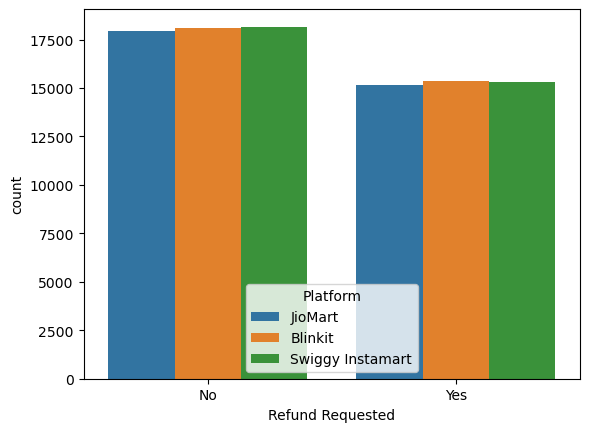

In [93]:
sns.countplot(x=df["Refund Requested"],hue=df["Platform"])
plt.show()

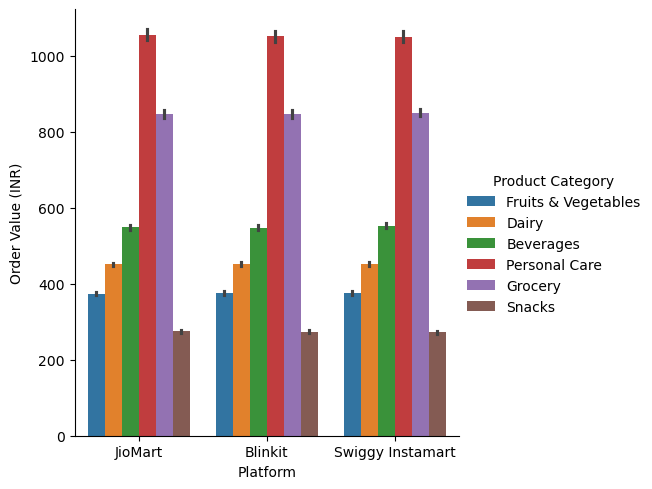

In [100]:
sns.catplot(x=df['Platform'],y=df['Order Value (INR)'], kind='bar',hue=df['Product Category'])
plt.show()